# PhysiCar ROS 2

ROS 2 interfaces and the Web API of the PhysiCar robot — same layout as the physicar-ros README.

## [1] ROS 2 Interfaces

### 1.0. Setup

One node shared by every example in this notebook. Re-running is safe — `rclpy.init()` runs only once per kernel.

In [1]:
import json
import math
import time

import requests

import rclpy
from rclpy.qos import qos_profile_sensor_data
from rclpy.wait_for_message import wait_for_message
from IPython.display import Image, display
from geometry_msgs.msg import Twist
from nav_msgs.msg import Odometry
from sensor_msgs.msg import BatteryState, CompressedImage, Imu, LaserScan
from std_msgs.msg import Float64

rclpy.init()

node = rclpy.create_node("tutorial")

BASE_URL = "http://localhost"

### 1.1. Sensors

`wait_for_message` receives a single message without spinning — ideal for notebooks.

#### 1.1.1. Camera

`/camera/image_raw/compressed` · [`CompressedImage`](https://docs.ros2.org/latest/api/sensor_msgs/msg/CompressedImage.html)

Camera image (JPEG) — the payload is a ready-to-display JPEG, no decoding needed.

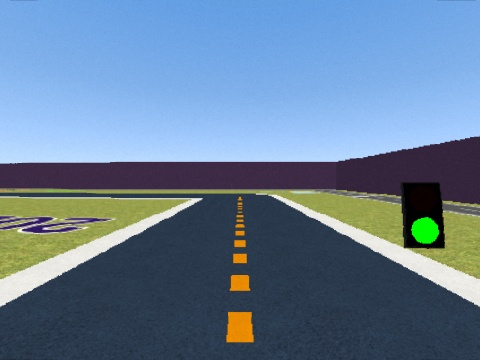

In [2]:
ok, image = wait_for_message(CompressedImage, node, "/camera/image_raw/compressed", time_to_wait=2.0)
display(Image(data=bytes(image.data)))

#### 1.1.2. Battery

`/battery_state` · [`BatteryState`](https://docs.ros2.org/latest/api/sensor_msgs/msg/BatteryState.html)

Battery state (1 Hz). `percentage` is a 0–1 ratio.

In [3]:
ok, battery = wait_for_message(BatteryState, node, "/battery_state", time_to_wait=3.0)
print(f"voltage: {battery.voltage:.2f} V  charge: {battery.percentage:.0%}")

voltage: 8.40 V  charge: 100%


#### 1.1.3. IMU

`/imu` · [`Imu`](https://docs.ros2.org/latest/api/sensor_msgs/msg/Imu.html)

IMU (50 Hz).

In [4]:
ok, imu = wait_for_message(Imu, node, "/imu", time_to_wait=2.0)
av, la = imu.angular_velocity, imu.linear_acceleration
print(f"angular velocity    : x={av.x:.3f}  y={av.y:.3f}  z={av.z:.3f} rad/s")
print(f"linear acceleration : x={la.x:.3f}  y={la.y:.3f}  z={la.z:.3f} m/s^2")

angular velocity    : x=0.000  y=-0.001  z=0.000 rad/s
linear acceleration : x=0.008  y=0.027  z=9.811 m/s^2


#### 1.1.4. Odometry

`/odom` · [`Odometry`](https://docs.ros2.org/latest/api/nav_msgs/msg/Odometry.html)

Odometry.

In [5]:
ok, odom = wait_for_message(Odometry, node, "/odom", time_to_wait=2.0)
pos, vel = odom.pose.pose.position, odom.twist.twist
print(f"position : x={pos.x:.3f}  y={pos.y:.3f}")
print(f"velocity : linear={vel.linear.x:.3f} m/s  angular={vel.angular.z:.3f} rad/s")

position : x=-0.009  y=0.021
velocity : linear=-0.023 m/s  angular=0.000 rad/s


#### 1.1.5. LiDAR (raw)

`/scan` · [`LaserScan`](https://docs.ros2.org/latest/api/sensor_msgs/msg/LaserScan.html)

LiDAR scan (raw). LiDAR publishes with best-effort sensor QoS — the subscription must pass `qos_profile_sensor_data` to match.

In [6]:
ok, scan = wait_for_message(LaserScan, node, "/scan",
                            qos_profile=qos_profile_sensor_data, time_to_wait=3.0)
print([round(r, 3) for r in scan.ranges])

[3.578, 3.57, 3.569, 3.578, 3.567, 3.57, 3.582, 3.587, 3.578, 3.587, 3.595, 3.602, 1.337, 1.338, 1.32, 1.3, 1.313, 1.287, 1.314, 1.285, 1.308, 1.342, 3.643, 3.655, 3.655, 3.66, 3.674, 3.688, 3.692, 3.697, 3.701, 3.737, 3.741, 3.735, 3.747, 3.752, 3.782, 3.782, 3.794, 3.792, 3.834, 3.824, 3.839, 3.821, 3.746, 3.651, 3.567, 3.483, 3.434, 3.388, 3.317, 3.232, 3.188, 3.13, 3.091, 3.04, 2.98, 2.937, 2.868, 2.826, 2.826, 2.764, 2.693, 2.672, 2.618, 2.624, 2.582, 2.532, 2.497, 2.466, 2.455, 2.416, 2.372, 2.376, 2.328, 2.309, 2.263, 2.256, 2.21, 2.197, 2.16, 2.15, 2.128, 2.116, 2.099, 2.086, 2.04, 2.033, 2.015, 1.99, 1.966, 1.976, 1.959, 1.945, 1.9, 1.877, 1.862, 1.854, 1.85, 1.824, 1.815, 1.816, 1.811, 1.794, 1.785, 1.763, 1.75, 1.727, 1.722, 1.726, 1.7, 1.702, 1.69, 1.698, 1.664, 1.656, 1.656, 1.646, 1.625, 1.602, 1.615, 1.608, 1.601, 1.578, 1.596, 1.573, 1.568, 1.569, 1.541, 1.547, 1.556, 1.535, 1.526, 1.534, 1.539, 1.499, 1.503, 1.504, 1.501, 1.5, 1.476, 1.489, 1.485, 1.47, 1.475, 1.47, 1.

#### 1.1.6. LiDAR (filtered)

`/scan_filtered` · [`LaserScan`](https://docs.ros2.org/latest/api/sensor_msgs/msg/LaserScan.html)

LiDAR scan (filtered).

In [7]:
ok, scan_filtered = wait_for_message(LaserScan, node, "/scan_filtered",
                                     qos_profile=qos_profile_sensor_data, time_to_wait=3.0)
print([round(r, 3) for r in scan_filtered.ranges])

[3.594, 3.565, 3.583, 3.574, 3.568, 3.576, 3.579, 3.571, 3.595, 3.588, 3.58, 3.59, 1.356, 1.321, 1.325, 1.307, 1.291, 1.327, 1.311, 1.308, 1.319, 1.336, 3.65, 3.637, 3.665, 3.671, 3.677, 3.705, 3.69, 3.696, 3.698, 3.696, 3.722, 3.744, 3.76, 3.742, 3.762, 3.799, 3.8, 3.805, 3.792, 3.814, 3.848, 3.795, 3.728, 3.669, 3.571, 3.512, 3.453, 3.392, 3.303, 3.231, 3.189, 3.124, 3.069, 3.035, 2.97, 2.935, 2.899, 2.834, 2.773, 2.752, 2.707, 2.672, 2.645, 2.616, 2.586, 2.539, 2.503, 2.464, 2.437, 2.408, 2.371, 2.357, 2.309, 2.301, 2.276, 2.234, 2.227, 2.216, 2.178, 2.162, 2.139, 2.11, 2.092, 2.037, 2.052, 2.039, 2.002, 2.001, 1.988, 1.962, 1.955, 1.915, 1.917, 1.874, 1.869, 1.868, 1.844, 1.83, 1.824, 1.82, 1.809, 1.788, 1.785, 1.778, 1.748, 1.738, 1.742, 1.71, 1.703, 1.7, 1.692, 1.663, 1.66, 1.648, 1.663, 1.643, 1.63, 1.61, 1.608, 1.611, 1.594, 1.602, 1.579, 1.574, 1.59, 1.566, 1.552, 1.543, 1.547, 1.525, 1.54, 1.524, 1.526, 1.495, 1.508, 1.525, 1.515, 1.495, 1.47, 1.489, 1.466, 1.446, 1.47, 1.46,

In [8]:
import math

ranges = list(scan_filtered.ranges)

valid = [
    (i, r) for i, r in enumerate(ranges)
    if math.isfinite(r) and r > 0
]

min_idx, min_dist = min(valid, key=lambda x: x[1])

angle_rad = scan_filtered.angle_min + min_idx * scan_filtered.angle_increment
angle_deg = math.degrees(angle_rad)

print("전체 데이터 개수 :", len(ranges))
print("가장 가까운 거리 :", round(min_dist, 3), "m")
print("인덱스 :", min_idx)
print("각도 :", round(angle_deg, 1), "deg")

print("\n주변 값:")
start = max(0, min_idx - 10)
end = min(len(ranges), min_idx + 11)

for i in range(start, end):
    print(i, round(ranges[i], 3))

전체 데이터 개수 : 720
가장 가까운 거리 : 1.291 m
인덱스 : 16
각도 : -172.0 deg

주변 값:
6 3.579
7 3.571
8 3.595
9 3.588
10 3.58
11 3.59
12 1.356
13 1.321
14 1.325
15 1.307
16 1.291
17 1.327
18 1.311
19 1.308
20 1.319
21 1.336
22 3.65
23 3.637
24 3.665
25 3.671
26 3.677


In [9]:
import math

def get_sector_min(scan, min_deg, max_deg):
    values = []

    for i, r in enumerate(scan.ranges):
        angle = scan.angle_min + i * scan.angle_increment
        angle_deg = math.degrees(angle)

        if min_deg <= angle_deg <= max_deg:
            if math.isfinite(r) and r > 0:
                values.append(r)

    return min(values) if values else float("inf")


front = get_sector_min(scan_filtered, -10, 10)
left  = get_sector_min(scan_filtered, 10, 45)
right = get_sector_min(scan_filtered, -45, -10)

print("LEFT :", round(left, 3))
print("FRONT:", round(front, 3))
print("RIGHT:", round(right, 3))

LEFT : 3.476
FRONT: 3.406
RIGHT: 1.985


### 1.2. Control

Publishing needs a discovered subscriber — each cell waits for the driver before sending (a message published before matching is lost).

#### 1.2.1. Velocity + Steering

`/cmd_vel` · [`Twist`](https://docs.ros2.org/latest/api/geometry_msgs/msg/Twist.html)

Velocity + steering (Ackermann conversion): `linear.x` is speed (m/s), `angular.z` is turn rate (rad/s). Drive commands expire after ~1 s (`cmd_timeout`) without renewal — the speed stops but the wheels keep their angle. A zero `Twist()` is an explicit stop that also recenters the steering.

In [10]:
cmd_vel_pub = node.create_publisher(Twist, "/cmd_vel", 10)
while cmd_vel_pub.get_subscription_count() == 0:
    time.sleep(0.1)

msg = Twist()
msg.linear.x = 0.5
msg.angular.z = 0.5
cmd_vel_pub.publish(msg)

#### 1.2.2. Speed

`/speed` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Speed (m/s) — commands expire after the driver's `cmd_timeout` (default 1 s, `0` disables) without renewal; publish periodically for sustained driving.

In [11]:
speed_pub = node.create_publisher(Float64, "/speed", 10)
while speed_pub.get_subscription_count() == 0:
    time.sleep(0.1)

speed_pub.publish(Float64(data=0.5))

#### 1.2.3. Steering

`/steering` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Steering angle (rad) — + = left, max ±20° (±0.35 rad).

In [12]:
steering_pub = node.create_publisher(Float64, "/steering", 10)
while steering_pub.get_subscription_count() == 0:
    time.sleep(0.1)

steering_pub.publish(Float64(data=math.radians(10)))

#### 1.2.4. Camera Pan

`/camera/pan` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Camera pan (rad) — + = left, range ±30° (±0.52 rad).

In [13]:
pan_pub = node.create_publisher(Float64, "/camera/pan", 10)
while pan_pub.get_subscription_count() == 0:
    time.sleep(0.1)

pan_pub.publish(Float64(data=math.radians(15)))

#### 1.2.5. Camera Tilt

`/camera/tilt` · [`Float64`](https://docs.ros2.org/latest/api/std_msgs/msg/Float64.html)

Camera tilt (rad) — + = up, range ±30° (±0.52 rad).

In [14]:
tilt_pub = node.create_publisher(Float64, "/camera/tilt", 10)
while tilt_pub.get_subscription_count() == 0:
    time.sleep(0.1)

tilt_pub.publish(Float64(data=math.radians(15)))

## [2] Web API

The same interfaces over HTTP — interactive docs at `/docs` (OpenAPI).

### 2.1. Sensor Queries

Query endpoints support real-time streaming via `?stream=true` (camera uses MJPEG, others use SSE).

#### 2.1.1. States

`GET /states` — full state snapshot, select with `?include=odom,battery,imu`.

In [15]:
requests.get(f"{BASE_URL}/states", params={"include": "odom,battery"}).json()

{'cmd': {'speed': 0.0, 'steering': 0.0, 'pan': 0.0, 'tilt': 0.0},
 'odom': {'position': {'x': 0.7997, 'y': 0.5762, 'z': 0.0},
  'orientation': {'yaw': 64.21,
   'quaternion': {'x': 0.0, 'y': 0.0, 'z': 0.5315, 'w': 0.8471}},
  'velocity': {'linear': -0.0017, 'angular': 0.0},
  'frame_id': 'odom'},
 'battery': {'voltage': 8.4,
  'percentage': 100.0,
  'current': 0.0,
  'charging': False,
  'present': True},
 'imu': {'acceleration': {'x': 0.0016, 'y': 0.0175, 'z': 9.7922},
  'gyro': {'x': 0.0, 'y': 0.0001, 'z': -0.0001},
  'orientation': {'x': -0.0, 'y': 0.0, 'z': 0.4903, 'w': 0.8715}},
 'lidar': {'step': 1.0,
  'count': 360,
  'range_min': 0.1,
  'range_max': 16.0,
  'ranges': {'-180': 2.226,
   '-179': 2.237,
   '-178': 2.199,
   '-177': 2.165,
   '-176': 2.167,
   '-175': 2.141,
   '-174': 2.127,
   '-173': 2.121,
   '-172': 2.087,
   '-171': 2.069,
   '-170': 2.072,
   '-169': 2.047,
   '-168': 2.036,
   '-167': 2.041,
   '-166': 2.011,
   '-165': 2.0,
   '-164': 1.983,
   '-163': 1.9

#### 2.1.2. Speed

`GET /speed` — speed (m/s).

In [16]:
requests.get(f"{BASE_URL}/speed").json()

-0.0085

#### 2.1.3. Steering

`GET /steering` — steering angle (rad).

In [17]:
requests.get(f"{BASE_URL}/steering").json()

0.0

#### 2.1.4. Odometry

`GET /odom`

In [18]:
requests.get(f"{BASE_URL}/odom").json()

{'position': {'x': 0.8074, 'y': 0.5849, 'z': 0.0},
 'orientation': {'yaw': 64.45,
  'quaternion': {'x': 0.0, 'y': 0.0, 'z': 0.5332, 'w': 0.846}},
 'velocity': {'linear': -0.0088, 'angular': 0.0},
 'frame_id': 'odom'}

#### 2.1.5. Battery

`GET /battery`

In [19]:
requests.get(f"{BASE_URL}/battery").json()

{'voltage': 8.4,
 'percentage': 100.0,
 'current': 0.0,
 'charging': False,
 'present': True}

#### 2.1.6. IMU

`GET /imu`

In [20]:
requests.get(f"{BASE_URL}/imu").json()

{'acceleration': {'x': 0.0137, 'y': 0.0028, 'z': 9.7593},
 'gyro': {'x': 0.0001, 'y': 0.0001, 'z': -0.0005},
 'orientation': {'x': -0.0, 'y': 0.0, 'z': 0.4903, 'w': 0.8715}}

#### 2.1.7. LiDAR

`GET /lidar` — scan with `ranges`, `range_min`/`range_max`, `count`.

In [21]:
lidar = requests.get(f"{BASE_URL}/lidar").json()
print(lidar["count"], "points")
print(lidar["ranges"])

360 points
{'-180': 2.272, '-179': 2.236, '-178': 2.209, '-177': 2.186, '-176': 2.166, '-175': 2.159, '-174': 2.136, '-173': 2.117, '-172': 2.112, '-171': 2.095, '-170': 2.073, '-169': 2.067, '-168': 2.042, '-167': 2.043, '-166': 2.026, '-165': 2.013, '-164': 1.992, '-163': 1.995, '-162': 1.973, '-161': 1.973, '-160': 1.967, '-159': 1.973, '-158': 1.954, '-157': 1.962, '-156': 1.93, '-155': 1.962, '-154': 1.955, '-153': 1.964, '-152': 1.917, '-151': 1.944, '-150': 1.935, '-149': 1.942, '-148': 1.925, '-147': 1.946, '-146': 1.924, '-145': 1.937, '-144': 1.94, '-143': 1.935, '-142': 1.943, '-141': 1.941, '-140': 1.974, '-139': 1.96, '-138': 1.954, '-137': 1.968, '-136': 1.971, '-135': 1.987, '-134': 1.993, '-133': 2.023, '-132': 2.027, '-131': 2.048, '-130': 2.046, '-129': 2.048, '-128': 2.07, '-127': 2.095, '-126': 2.102, '-125': 2.106, '-124': 2.111, '-123': 2.144, '-122': 2.171, '-121': 2.189, '-120': 2.202, '-119': 2.245, '-118': 2.24, '-117': 2.292, '-116': 2.287, '-115': 2.325, '-1

In [22]:
import math

def get_sector_min(scan, min_deg, max_deg):
    values = []

    for i, r in enumerate(scan.ranges):
        angle = scan.angle_min + i * scan.angle_increment
        angle_deg = math.degrees(angle)

        if min_deg <= angle_deg <= max_deg:
            if math.isfinite(r) and r > 0:
                values.append(r)

    return min(values) if values else float("inf")


front = get_sector_min(scan_filtered, -10, 10)
left  = get_sector_min(scan_filtered, 10, 45)
right = get_sector_min(scan_filtered, -45, -10)

print("LEFT :", round(left, 3))
print("FRONT:", round(front, 3))
print("RIGHT:", round(right, 3))

LEFT : 3.476
FRONT: 3.406
RIGHT: 1.985


#### 2.1.8. Camera

`GET /camera` — camera image (JPEG), resize with `?width`/`?height`.

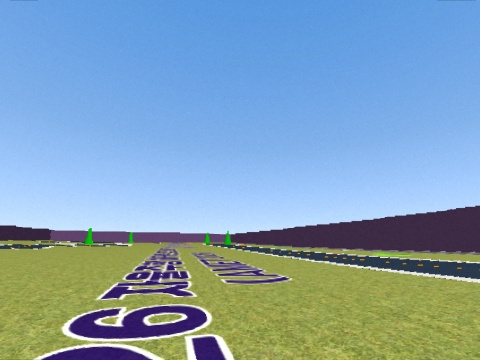

In [23]:
jpg = requests.get(f"{BASE_URL}/camera", params={"width": 480}).content
display(Image(data=jpg))

#### 2.1.9. Camera Pan

`GET /camera/pan` — pan angle (rad).

In [24]:
requests.get(f"{BASE_URL}/camera/pan").json()

0.0

#### 2.1.10. Camera Tilt

`GET /camera/tilt` — tilt angle (rad).

In [25]:
requests.get(f"{BASE_URL}/camera/tilt").json()

0.0

### 2.2. Control

POST the same `{"value": ...}` body everywhere. Speed follows the same `cmd_timeout` contract as the `/speed` topic.

#### 2.2.1. Speed

`POST /speed` — `{"value": m/s, "duration": seconds?}`. Without `duration` it expires after `cmd_timeout` (~1 s) unless renewed. With `duration` the server keeps the command alive, publishes 0 at the end, and the response returns after the drive finishes.

In [26]:
requests.post(f"{BASE_URL}/speed", json={"value": 0.5, "duration": 2.0}, timeout=10).json()

{'success': True, 'value': 0.5, 'message': 'stopped'}

#### 2.2.2. Steering

`POST /steering` — steering angle (rad), persists until changed.

In [27]:
requests.post(f"{BASE_URL}/steering", json={"value": math.radians(10)}).json()

{'success': True, 'value': 0.17453292519943295, 'message': None}

#### 2.2.3. Camera Pan

`POST /camera/pan`

In [28]:
requests.post(f"{BASE_URL}/camera/pan", json={"value": math.radians(15)}).json()

{'success': True, 'value': 0.2617993877991494, 'message': None}

#### 2.2.4. Camera Tilt

`POST /camera/tilt`

In [29]:
requests.post(f"{BASE_URL}/camera/tilt", json={"value": math.radians(15)}).json()

{'success': True, 'value': 0.2617993877991494, 'message': None}

#### 2.2.5. Streaming write (WebSocket)

`WS /speed/stream`, `/steering/stream` — each frame is the same `{"value": x}` as the POST. Dead-man switch: on disconnect the value is zeroed, so a dead client can never leave the robot driving.

In [30]:
from websockets.sync.client import connect

with connect("ws://localhost/speed/stream") as ws:
    for _ in range(20):  # ~2 s of driving at 10 Hz
        ws.send(json.dumps({"value": 0.5}))
        time.sleep(0.1)
# socket closed -> the dead-man switch zeroes the speed

ModuleNotFoundError: No module named 'websockets.sync'

### 2.3. Audio

Command-based playback on the robot speaker (played in the browser viewer in SIM).

#### 2.3.1. Play

`POST /audio/play` — one of `url` / `path` / `data` (base64). Options: `volume` (0–1), `loop`, `replace`.

In [32]:
import struct
import wave

path = "/tmp/beep.wav"
with wave.open(path, "w") as f:
    f.setnchannels(1)
    f.setsampwidth(2)
    f.setframerate(24000)
    f.writeframes(b"".join(struct.pack("<h", int(8000 * math.sin(2 * math.pi * 440 * t / 24000)))
                           for t in range(24000)))  # 1 s, 440 Hz

requests.post(f"{BASE_URL}/audio/play", json={"path": path, "volume": 0.8}).json()

{'success': True, 'id': '98552edc', 'duration': 1.0}

#### 2.3.2. Now playing

`GET /audio`

In [33]:
requests.get(f"{BASE_URL}/audio").json()

{'playing': []}

#### 2.3.3. Stop

`POST /audio/stop` — by `id`, or everything with `{"all": true}`.

In [34]:
requests.post(f"{BASE_URL}/audio/stop", json={"all": True}).json()

{'success': True}